<a href="https://colab.research.google.com/github/kvlaskarolina/JU-sem6-IAI/blob/main/05_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    "font.family": "serif",
    'mathtext.fontset': 'dejavuserif'
})

In [3]:
def generate_spiral_data(num_samples: int):
    N = num_samples // 2

    theta = np.sqrt(np.random.rand(N))*4*np.pi

    r_a = 4*theta + np.pi
    data_a = np.array([np.cos(theta)*r_a, np.sin(theta)*r_a]).T
    x_a = data_a + np.random.randn(N,2) * 3
    label_a = np.array([0]*N)[:, None]


    r_b = -4*theta - np.pi
    data_b = np.array([np.cos(theta)*r_b, np.sin(theta)*r_b]).T
    x_b = data_b + np.random.randn(N,2) * 3
    label_b = np.array([1]*N)[:, None]

    x = np.concatenate([x_a, x_b], axis=0)
    x /= np.std(x, axis=0)
    y = np.concatenate([label_a, label_b], axis=0)
    return x, y.squeeze()

def plot_2d_data(x, y, edgecolors: str = None, alpha: float = 0.8, decision_boundary_params: dict = None):
    plt.figure(figsize=(8, 6))
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap="magma", s=50, alpha=alpha, vmin=0.0, vmax=y.max()+1, edgecolors=edgecolors,)
    plt.axis('equal')
    plt.xlabel(r"$x_0$", fontdict={'family': 'serif', 'size': 14,  'color': 'black'})
    plt.ylabel(r"$x_1$", fontdict={'family': 'serif', 'size': 14,  'color': 'black'})

    if decision_boundary_params:
        w0 = decision_boundary_params['w'][0].item()
        w1 = decision_boundary_params['w'][1].item()
        b = decision_boundary_params['b'].item()

        # Define the x-range for the decision boundary line
        x0_min, x0_max = plt.xlim()
        x_line = np.array([x0_min, x0_max])

        # Calculate corresponding y values based on Wx + b = 0 => x1 = -(w0*x0 + b) / w1
        if w1 != 0:
            x1_line = -(w0 * x_line + b) / w1
        else: # Handle vertical line case if w1 is zero (decision boundary is x0 = -b/w0)
            x0_line_val = -b / w0
            x_line = np.array([x0_line_val, x0_line_val])
            x1_min, x1_max = plt.ylim()
            x1_line = np.array([x1_min, x1_max])

        plt.plot(x_line, x1_line, 'b--', linewidth=2, label='Decision Boundary')
        plt.legend()

    plt.title('Transformed Data and Decision Boundary', fontdict={'family': 'serif', 'size': 16,  'color': 'black'})
    plt.show()
    plt.close()

In [29]:
x, y = generate_spiral_data(1000)

/tmp/ipykernel_14173/227093569.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


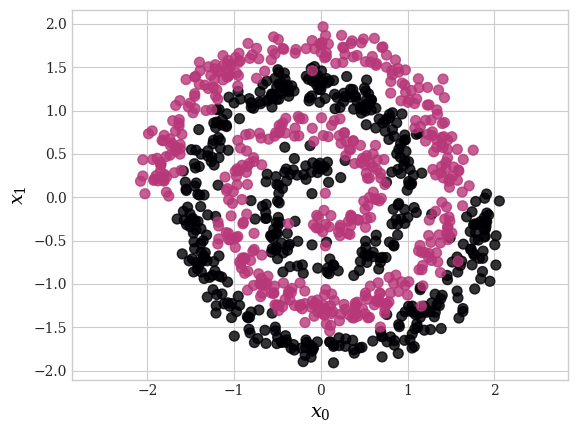

In [30]:
plot_2d_data(x, y)

# Zadanie I:
- Zbuduj model o nazwie *backbone* $f_b: \mathbb{R}^d \to \mathbb{R}^d$ składający się z bloku warstw: Linear -> BatchNorm -> GELU.

- Zbuduj model o nazwie *head* $f_h: \mathbb{R}^d \to (0, 1)$ składający się z jednej warstwy **Linear** i aktywacji **Sigmoid**.

- Wytrenuj model $f = f_h \circ f_b$ na wygenerowanych danych używając lossu **BinaryCrossEntropy** i optimizera **Adam** lub **SGD**.

- Po treningu policz skuteczność (accuracy) modelu.

- Powtórz eskperyment zwiększając liczbę bloków w modelu *backbone* (1 - 3), tak aby wymiarowość warstw pośrednich wynosiła 20, a wejściowej i wyjściowej 2. Zapisz accuracy dla każdej konfiguracji.



In [36]:
import torch
import torch.nn as nn
from torch import Tensor

class Backbone(nn.Module):
    def __init__(self, in_features: int, out_features: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(in_features, out_features),
            nn.BatchNorm1d(out_features),
            nn.GELU()
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.block(x)

class Head(nn.Module):
    def __init__(self, in_features: int, out_features: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(in_features, out_features),
            nn.Sigmoid()
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.block(x)

class NeuralNetwork(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int, num_blocks: int):
        super().__init__()
        layers = []
        for i in range(num_blocks):
            current_in = in_dim if i == 0 else hidden_dim
            layers.append(Backbone(current_in, hidden_dim))

        self.backbone = nn.Sequential(*layers)
        self.head = Head(hidden_dim, out_dim)

    def forward(self, x: Tensor) -> Tensor:
        x = self.backbone(x)
        return self.head(x)

x_tensor = torch.tensor(x, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)


in_features = x.shape[1] # 2
hidden_features = 2
out_features = 1

num_epochs = 1000
criterion = nn.BCELoss()

results = {}

for num_blocks in range(1, 4):
    print(f"\nTraining model with {num_blocks} backbone block(s)...")
    model = NeuralNetwork(in_features, hidden_features, out_features, num_blocks=num_blocks)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    for epoch in range(num_epochs):
        outputs = model(x_tensor)
        loss = criterion(outputs, y_tensor)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (epoch+1) % 200 == 0:
            print (f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

    model.eval()
    with torch.no_grad():
        predicted = (model(x_tensor) > 0.5).float()
        accuracy = (predicted == y_tensor).float().mean()
        print(f'Accuracy for {num_blocks} backbone block(s): {accuracy.item():.4f}')

    results[num_blocks] = accuracy.item()

print(f"\nFinal accuracy results for different backbone block configurations: {results}")


Training model with 1 backbone block(s)...
Epoch [200/1000], Loss: 0.6602
Epoch [400/1000], Loss: 0.6071
Epoch [600/1000], Loss: 0.5820
Epoch [800/1000], Loss: 0.5678
Epoch [1000/1000], Loss: 0.5621
Accuracy for 1 backbone block(s): 0.6380

Training model with 2 backbone block(s)...
Epoch [200/1000], Loss: 0.5275
Epoch [400/1000], Loss: 0.3983
Epoch [600/1000], Loss: 0.3896
Epoch [800/1000], Loss: 0.3838
Epoch [1000/1000], Loss: 0.3779
Accuracy for 2 backbone block(s): 0.3530

Training model with 3 backbone block(s)...
Epoch [200/1000], Loss: 0.5093
Epoch [400/1000], Loss: 0.5017
Epoch [600/1000], Loss: 0.4938
Epoch [800/1000], Loss: 0.4858
Epoch [1000/1000], Loss: 0.4785
Accuracy for 3 backbone block(s): 0.6600

Final accuracy results for different backbone block configurations: {1: 0.6380000114440918, 2: 0.3529999852180481, 3: 0.6600000262260437}


# Zadanie II
- Dla *backbone* o głębokości 3 z poprzedniego zadania, zwizualizuj dane po przejściu przez *backbone* za pomocą:
```
plot_2d_data(backbone(x).detach(), y.detach())
```
- Dodatkowo, zwizualizuj granicę decyzji modelu head i nanieś ją na powyższą wizualizację. Jako granicę rozumiemy prostą:
```
head(x) = 0.5
```
poprzez sigmoide: $head(x) = \sigma(Wx+b)$ jest to hiperpłaszczyzna $Wx + b = 0$, gdzie $W$ i $b$ są parametrami *weight* i *bias* warstwy *Linear*. A że pracujemy w dwóch wymiarach to jest to prosta: $w_0x_0 + w_1x_1 + b = 0$, czyli $x_1 = -\dfrac{w_0x_0+b}{w_1}$


- Jaka wdł. Ciebie jest rola backbone i head w MLP na podstawie wizualizacji?



/tmp/ipykernel_14173/1549740623.py:13: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  x1_decision_boundary = -(weights[0] * x0_range + bias) / weights[1]


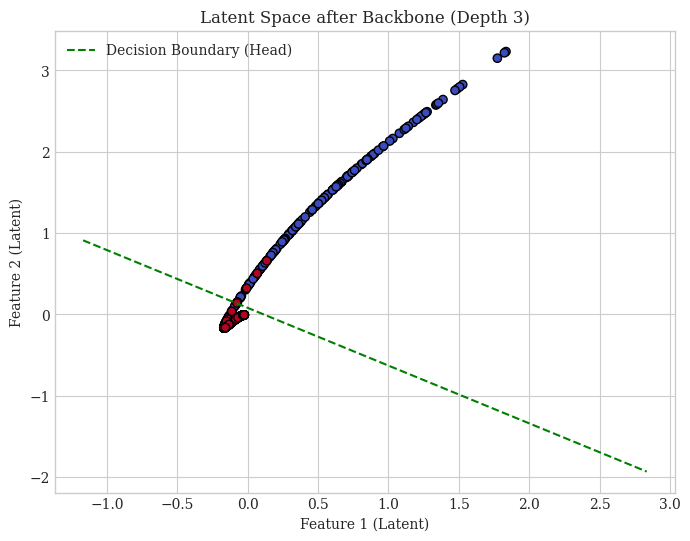

In [40]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_model_internals(model, x_tensor, y_tensor):
    model.eval()
    with torch.no_grad():
        latent_space = model.backbone(x_tensor).detach()

        weights = model.head.block[0].weight[0].detach().numpy()
        bias = model.head.block[0].bias[0].detach().numpy()

        x0_range = np.linspace(latent_space[:, 0].min() - 1, latent_space[:, 0].max() + 1, 100)
        x1_decision_boundary = -(weights[0] * x0_range + bias) / weights[1]

        plt.figure(figsize=(8, 6))
        plt.scatter(latent_space[:, 0], latent_space[:, 1], c=y_tensor.flatten(), cmap='coolwarm', edgecolors='k')
        plt.plot(x0_range, x1_decision_boundary, 'g--', label='Decision Boundary (Head)')

        plt.title(f"Latent Space after Backbone (Depth 3)")
        plt.xlabel("Feature 1 (Latent)")
        plt.ylabel("Feature 2 (Latent)")
        plt.legend()
        plt.grid(True)
        plt.show()

visualize_model_internals(model, x_tensor, y_tensor)

Na podstawie wizualizacji, rola *backbone* jest transformacja oryginalnych, nieliniowo rozdzielalnych danych w przestrzeń, gdzie klasy są liniowo separowalne. W tym przypadku, po przejściu przez *backbone*, dane, które pierwotnie tworzyły spirale, zostały przekształcone w dwie oddzielne grupy, które można rozdzielić prostą linią.

Rola *head* sprowadza się do nauczenia się tej liniowej granicy decyzji w przestrzeni cech utworzonej przez *backbone*. Ponieważ dane są już liniowo rozdzielalne, *head* (złożony z warstwy liniowej i sigmoidu) może łatwo znaleźć optymalną hiperpłaszczyznę (linię w 2D), która dzieli te klasy.